#### Dataset
- Name: Titanic Dataset
- Task: Binary Classification
- Source: Kaggle
- Reference: Link: https://www.kaggle.com/c/titanic


<h1> Gradient Boosting

Here, we can see the difference between two important ensemble families:


| Method            | Core Idea                                                                  |
| ----------------- | -------------------------------------------------------------------------- |
| Decision Tree     | A single tree                                                              |
| Random Forest     | Multiple independent trees + Bootstrap + Voting                            |
| Gradient Boosting | Trees are built sequentially, and each tree corrects previous errors       |

Key difference from the previous Decision Tree Classification:

In Classification:</br>
Leaf → Majority class

In Regression:</br>
Leaf → Mean of values

#### Split criterion</br>
In Decision Tree Classification:</br>
- Gini</br>
- Entropy

In Regression:</br>
MSE (Mean Squared Error)

The best split is the one that minimizes the error within each group after the data is divided.
Formula:

$MSE = \frac{1}{n}\sum(y-\bar{y})^2$

The difference between each value and the mean of its own group.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

from src.gradient_boosting import (
    RegressionTree,
    GradientBoosting,
)

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

<h3> Step 1: Initial Regression Tree test

In [20]:
X = np.array(
    [
        [1],
        [2],
        [3],
        [10],
        [11],
        [12]
    ]
)

y = np.array(
    [
        10,
        20,
        30,
        100,
        110,
        120
    ]
)

Build Model

In [21]:
tree = RegressionTree(
    max_depth=2
)

tree.fit(
    X,
    y
)

Predict

In [22]:
tree.predict(
    np.array(
        [
            [2],
            [11]
        ]
    )
)

array([ 25., 115.])

In [23]:
tree.print_tree()

 Feature 0 <= 6.5
   Feature 0 <= 1.5
     Leaf: 10.0
     Leaf: 25.0
   Feature 0 <= 10.5
     Leaf: 100.0
     Leaf: 115.0


<h3> Step 2: Implement Gradient Boosting

$y = 2x$

In [24]:
X = np.array(
    [
        [1],
        [2],
        [3],
        [4],
        [5],
        [6]
    ]
)

y = np.array(
    [
        2,
        4,
        6,
        8,
        10,
        12
    ]
)

In [25]:
gb = GradientBoosting(
    n_estimators=15,
    learning_rate=0.1,
    max_depth=2
)

In [26]:
gb.fit(
    X,
    y
)

Tree: 1 Residual MSE: 11.666666666666666
Tree: 2 Residual MSE: 9.576666666666666
Tree: 3 Residual MSE: 7.848616666666666
Tree: 4 Residual MSE: 6.448896166666665
Tree: 5 Residual MSE: 5.290967932916664
Tree: 6 Residual MSE: 4.352914498257288
Tree: 7 Residual MSE: 3.5745354104030156
Tree: 8 Residual MSE: 2.9440483492410543
Tree: 9 Residual MSE: 2.4204245034471574
Tree: 10 Residual MSE: 1.9962891883540996
Tree: 11 Residual MSE: 1.6369049219065908
Tree: 12 Residual MSE: 1.3458036660841086
Tree: 13 Residual MSE: 1.1048530288730545
Tree: 14 Residual MSE: 0.9074334855823403
Tree: 15 Residual MSE: 0.7432467996500608


As the number of trees increases, the model's accuracy also increases.

In [27]:
predictions = gb.predict(
    np.array(
        [
            [1],
            [3],
            [6]
        ]
    )
)

predictions

array([ 3.22033235,  6.08891636, 10.81777983])

Gradient Boosting is not inherently stochastic.
So, if you provide the same data, the same parameters, and the same execution order, it usually yields exactly the same output.

<h3> Step 3: Running Gradient Boosting Classifier on Titanic

In [ ]:
df = pd.read_csv(
    "../../../datasets/Titanic-Dataset/processed/titanic_feature_engineered.csv"
)

X = df.drop("Survived", axis=1)
y = df["Survived"]

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [29]:
gb_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [30]:
gb_classifier.fit(
    X_train_processed,
    y_train
)

GradientBoostingClassifier(random_state=42)

In [31]:
y_pred_gb = gb_classifier.predict(
    X_test_processed
)

In [ ]:
gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

gb_precision = precision_score(
    y_test,
    y_pred_gb
)

gb_recall = recall_score(
    y_test,
    y_pred_gb
)

gb_f1 = f1_score(
    y_test,
    y_pred_gb
)

gb_cm = confusion_matrix(
    y_test,
    y_pred_gb
)

In [33]:
gb_result = pd.DataFrame(
    {
        "Model": [
            "Gradient Boosting"
        ],

        "Accuracy": [
            gb_accuracy
        ],

        "Precision": [
            gb_precision
        ],

        "Recall": [
            gb_recall
        ],

        "F1-score": [
            gb_f1
        ],

        "Confusion Matrix": [
            gb_cm.tolist()
        ]
    }
)

gb_result

,Model,Accuracy,Precision,Recall,F1-score,Confusion Matrix
0,Gradient Boosting,0.815642,0.790323,0.710145,0.748092,"[[97, 13], [20, 49]]"


Based on the outputs, approximately 79% of the individuals predicted by the model actually survived. The model is relatively conservative.

| Model | Accuracy |
|-|-:|
| Custom Random Forest | 83.24% |
| Custom Decision Tree | 82.12% |
| Logistic Regression | 82.68% |
| Gradient Boosting | 81.56% |

With the current settings, Gradient Boosting has not yet outperformed the previous models.</br>
However, this is not unusual, as Gradient Boosting is highly sensitive to hyperparameters.

Gradient Boosting:
usually improves with tuning.</br>
typically excels with larger datasets.</br>
can learn complex patterns, but the quality of the features is crucial.

### Initial Gradient Boosting Evaluation

The first Gradient Boosting model was trained using:

- n_estimators = 100
- learning_rate = 0.1
- max_depth = 3

The model achieved:

| Metric | Score |
|---|---:|
| Accuracy | 0.8156 |
| Precision | 0.7903 |
| Recall | 0.7101 |
| F1-score | 0.7481 |

The model achieved reasonable performance but did not outperform Random Forest with the initial parameters.

Since Gradient Boosting is highly sensitive to hyperparameters, further experiments were performed by changing the number of estimators, learning rate, and tree depth to improve performance.

<h3> Step 4: Hyperparameter Analysis on Gradient Boosting

We examine three important parameters:
1. n_estimators
2. learning_rate
3. max_depth

<h3> Step 4.1: Effect of Number of Trees (n_estimators)

In [34]:
n_estimators_values = [
    10,
    25,
    50,
    100,
    150,
    200
]

n_estimators_results = []

for n in n_estimators_values:
    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(
        X_train_processed,
        y_train
    )

    y_pred = model.predict(
        X_test_processed
    )

    n_estimators_results.append(
        {
            "Number of Trees": n,
            "Accuracy": accuracy_score(
                y_test,
                y_pred
            ),
            "Precision": precision_score(
                y_test,
                y_pred
            ),
            "Recall": recall_score(
                y_test,
                y_pred
            ),
            "F1-score": f1_score(
                y_test,
                y_pred
            )
        }
    )

n_estimators_results = pd.DataFrame(
    n_estimators_results
)

n_estimators_results

,Number of Trees,Accuracy,Precision,Recall,F1-score
0,10,0.793296,0.796296,0.623188,0.699187
1,25,0.787709,0.738462,0.695652,0.716418
2,50,0.793296,0.758065,0.681159,0.717557
3,100,0.815642,0.790323,0.710145,0.748092
4,150,0.815642,0.800000,0.695652,0.744186
5,200,0.815642,0.790323,0.710145,0.748092


It initially improves as the number of trees increases, but eventually reaches a saturation point.

### Why doesn't it always improve like Random Forest?

In Random Forest:</br>
Each tree is independent.</br>
Therefore, adding trees usually reduces variance.

However, in Gradient Boosting:</br>
Each tree depends on the previous one.</br>
Beyond a certain point:
- the remaining residuals become very small
- new trees do not add much information
- the risk of overfitting increases

### Effect of Number of Trees

The number of boosting stages was evaluated by changing `n_estimators`.

Increasing the number of trees improved the model performance because additional trees were able to learn and correct remaining errors from previous stages.

The performance improved from:

- Accuracy: 79.33% with 10 trees
- Accuracy: 81.56% with 100 trees

After approximately 100 estimators, the model reached a performance plateau and additional trees did not provide meaningful improvement.

This shows that increasing the number of boosting stages improves learning initially, but after a certain point it provides diminishing returns and may increase the risk of overfitting.

<h3> Step 4.2: Effect of Learning Rate

In [35]:
n_estimators=100

learning_rates = [
    0.01,
    0.05,
    0.1,
    0.2,
    0.5
]

learning_rate_results = []

for lr in learning_rates:
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )

    model.fit(
        X_train_processed,
        y_train
    )

    y_pred = model.predict(
        X_test_processed
    )

    learning_rate_results.append(
        {
            "Learning Rate": lr,

            "Accuracy": accuracy_score(
                y_test,
                y_pred
            ),

            "Precision": precision_score(
                y_test,
                y_pred
            ),

            "Recall": recall_score(
                y_test,
                y_pred
            ),

            "F1-score": f1_score(
                y_test,
                y_pred
            )
        }
    )

learning_rate_results = pd.DataFrame(
    learning_rate_results
)

learning_rate_results

,Learning Rate,Accuracy,Precision,Recall,F1-score
0,0.01,0.793296,0.796296,0.623188,0.699187
1,0.05,0.815642,0.781250,0.724638,0.751880
2,0.10,0.815642,0.790323,0.710145,0.748092
3,0.20,0.810056,0.777778,0.710145,0.742424
4,0.50,0.810056,0.761194,0.739130,0.750000


### Effect of Learning Rate

The learning rate controls how much each new tree contributes to the final model.

Different learning rates were tested while keeping the number of estimators fixed at 100.

The results showed that a very small learning rate (0.01) caused underfitting because each tree made only small corrections. Increasing the learning rate improved the performance, with the best F1-score achieved at:

- Learning Rate: 0.05
- F1-score: 0.7519

Higher learning rates (0.2 and 0.5) slightly reduced accuracy, showing that larger updates can increase the risk of overfitting.

The experiment demonstrates the trade-off between learning speed and model generalization.

<h3> Step 4.3: Effect of Tree Depth (max_depth)

If any individual tree is too strong, it might quickly focus on the noise in the data.

In [36]:
n_estimators = 100
learning_rate = 0.05

max_depth_values = [
    1,
    2,
    3,
    5,
    7
]

max_depth_results = []

for depth in max_depth_values:
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train_processed,
        y_train
    )

    y_pred = model.predict(
        X_test_processed
    )

    max_depth_results.append(
        {
            "Max Depth": depth,
            "Accuracy": accuracy_score(
                y_test,
                y_pred
            ),
            "Precision": precision_score(
                y_test,
                y_pred
            ),
            "Recall": recall_score(
                y_test,
                y_pred
            ),
            "F1-score": f1_score(
                y_test,
                y_pred
            )
        }
    )

max_depth_results = pd.DataFrame(
    max_depth_results
)

max_depth_results

,Max Depth,Accuracy,Precision,Recall,F1-score
0,1,0.793296,0.766667,0.666667,0.713178
1,2,0.804469,0.774194,0.695652,0.732824
2,3,0.815642,0.781250,0.724638,0.751880
3,5,0.810056,0.769231,0.724638,0.746269
4,7,0.826816,0.779412,0.768116,0.773723


This experiment yielded an interesting result because, contrary to common expectations, greater tree depth led to improvements in this dataset. Let’s analyze this.

### Effect of Tree Depth

The maximum depth of individual trees was evaluated while keeping:

- n_estimators = 100
- learning_rate = 0.05

The results showed that shallow trees underfit the dataset because they were not complex enough to capture meaningful patterns.

Increasing the depth improved performance, with the best result achieved at:

- max_depth = 7
- Accuracy = 82.68%
- F1-score = 77.37%

Although deeper trees can increase the risk of overfitting, in this experiment the additional complexity helped the model capture more useful patterns from the engineered features.

<h3> Step 5: Final Gradient Boosting Model

In [37]:
final_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=7,
    random_state=42
)

In [38]:
final_gb.fit(
    X_train_processed,
    y_train
)

GradientBoostingClassifier(learning_rate=0.05, max_depth=7, random_state=42)

In [39]:
y_pred_final_gb = final_gb.predict(
    X_test_processed
)

In [40]:
final_gb_accuracy = accuracy_score(
    y_test,
    y_pred_final_gb
)

final_gb_precision = precision_score(
    y_test,
    y_pred_final_gb
)

final_gb_recall = recall_score(
    y_test,
    y_pred_final_gb
)

final_gb_f1 = f1_score(
    y_test,
    y_pred_final_gb
)

final_gb_cm = confusion_matrix(
    y_test,
    y_pred_final_gb
)

In [43]:
print(
    classification_report(
        y_test,
        y_pred_final_gb
    )
)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       110
           1       0.78      0.77      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



<h3> Confusion Matrix Visualization

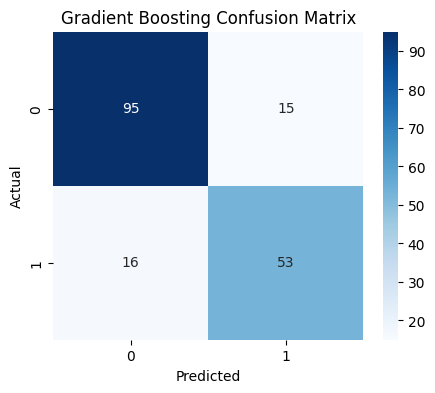

In [44]:
plt.figure(
    figsize=(5,4)
)

sns.heatmap(
    final_gb_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Gradient Boosting Confusion Matrix"
)

plt.show()

<h3> Creating the final model table

In [45]:
final_gb_result = pd.DataFrame(
    {
        "Model": [
            "Final Gradient Boosting"
        ],

        "Accuracy": [
            final_gb_accuracy
        ],

        "Precision": [
            final_gb_precision
        ],

        "Recall": [
            final_gb_recall
        ],

        "F1-score": [
            final_gb_f1
        ],

        "Confusion Matrix": [
            final_gb_cm.tolist()
        ]
    }
)

final_gb_result

,Model,Accuracy,Precision,Recall,F1-score,Confusion Matrix
0,Final Gradient Boosting,0.826816,0.779412,0.768116,0.773723,"[[95, 15], [16, 53]]"


| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.827 | 0.806 | 0.725 | 0.763 |
| KNN (k=25) | 0.821 | 0.794 | 0.725 | 0.758 |
| Naive Bayes | 0.771 | 0.656 | 0.855 | 0.742 |
| Decision Tree | 0.821 | 0.753 | 0.797 | 0.775 |
| Random Forest | 0.832 | 0.810 | 0.739 | 0.773 |
| Gradient Boosting | 0.827 | 0.779 | 0.768 | 0.774 |

- Random Forest achieved the highest accuracy (0.832).
- Decision Tree achieved the highest recall among the tree-based models (0.797).
- Naive Bayes has the highest overall recall (0.855), though its precision is lower.
- Despite its simplicity, Logistic Regression provided a very strong baseline.
- After tuning, Gradient Boosting nearly matched the performance of the tree-based models but did not demonstrate a clear advantage over Random Forest on this dataset.